# Temporal-shifting ceiling

This notebook implements the temporal-shifting ceiling analysis. It has two explicit stages:

1. Run `shift_ceiling_results.py` to cross the four raw replay workloads with the 36 sampled intensity windows. The generator excludes every context job, uses submission time as $r_j$, reads the real platform power states, and minimizes carbon and water independently.
2. Read the resulting job-level CSV and render the five analysis figures.

The scan deliberately ignores capacity and queue conflicts. Each job can independently occupy the best reachable valley, so these results are an optimistic ceiling rather than a feasible schedule.

In [1]:
from pathlib import Path
import subprocess
import sys

import numpy as np
import pandas as pd


def find_repository_root(start):
    for candidate in [start, *start.parents]:
        if (candidate / 'analysis' / 'shift_ceiling_results.py').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the experimental-artifacts checkout')


ROOT = find_repository_root(Path.cwd().resolve())
ANALYSIS_DIR = ROOT / 'analysis'
RESULTS_PATH = ANALYSIS_DIR / 'shift_ceiling_results.csv.gz'
FIGURE_DIR = ANALYSIS_DIR / 'figures'
GENERATOR_PATH = ANALYSIS_DIR / 'shift_ceiling_results.py'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_DIR))

import shift_ceiling_analysis as ca

ROOT, RESULTS_PATH, FIGURE_DIR

(PosixPath('/Users/lucas/Documents/experimental-artifacts'),
 PosixPath('/Users/lucas/Documents/experimental-artifacts/analysis/shift_ceiling_results.csv.gz'),
 PosixPath('/Users/lucas/Documents/experimental-artifacts/analysis/figures'))

## 1. Generate the CSV

A full run writes 10,338,192 rows. The file is gzip-compressed CSV because the uncompressed table is unnecessarily large. Set `REGENERATE_CSV = True` to force a fresh run. Otherwise the generator runs only when the result is missing.

In [2]:
REGENERATE_CSV = False

if REGENERATE_CSV or not RESULTS_PATH.exists():
    command = [
        sys.executable,
        str(GENERATOR_PATH),
        '--output',
        str(RESULTS_PATH),
    ]
    if RESULTS_PATH.exists():
        command.append('--overwrite')
    subprocess.run(command, cwd=ROOT, check=True)

print(f'{RESULTS_PATH.name}: {RESULTS_PATH.stat().st_size / 1024**2:.1f} MiB')

shift_ceiling_results.csv.gz: 267.9 MiB


## 2. Aggregate the job-level results

The loader streams the CSV in chunks. It retains only the 24-hour job-level rows and the displaced-job slowdown values needed for distributions. Savings are always calculated as a ratio of summed footprints, not as the mean of per-job percentages.

In [3]:
analysis = ca.load_results(RESULTS_PATH)
print(f'Rows: {analysis.row_count:,}')
print(
    'Workload-window pairs:',
    analysis.pair_summary[['workload', 'intensity_trace']].drop_duplicates().shape[0],
)
analysis.pair_summary.head()

Rows: 10,338,192
Workload-window pairs: 144


,workload,platform,zone,intensity_trace,season,year,d_m_label,d_m_seconds,signal,baseline,shifted,jobs,displaced_jobs,bsld_sum,saving_pct,displaced_pct,mean_bsld
0,mustang_stress,mustang,DE,DE_2019-02-04,winter,2019,0h,0,carbon,122287.065618,122287.065618,5089,0,5089.000000,0.000000,0.000000,1.000000
1,mustang_stress,mustang,DE,DE_2019-02-04,winter,2019,0h,0,water,524306.292250,524306.292250,5089,0,5089.000000,0.000000,0.000000,1.000000
2,mustang_stress,mustang,DE,DE_2019-02-04,winter,2019,1h,3600,carbon,122287.065618,121749.271069,5089,759,5242.987157,0.439780,14.914522,1.030259
3,mustang_stress,mustang,DE,DE_2019-02-04,winter,2019,1h,3600,water,524306.292250,522218.795544,5089,744,5230.351060,0.398145,14.619768,1.027776
4,mustang_stress,mustang,DE,DE_2019-02-04,winter,2019,3h,10800,carbon,122287.065618,120636.223182,5089,902,5598.298467,1.349973,17.724504,1.100078


## Headline values

The reference values provide regression checks for the analysis. The table keeps the computed values at full precision, then an assertion checks that they round to the expected values.

In [4]:
metrics = ca.headline_metrics(analysis)
comparison = pd.DataFrame(
    {
        'Computed': [
            metrics['aggregate_saving_pct']['carbon'],
            metrics['aggregate_saving_pct']['water'],
            metrics['displaced_jobs_pct']['carbon'],
            metrics['median_displacement_h_carbon'],
            metrics['mean_bsld_all_carbon'],
            metrics['mean_bsld_displaced_carbon'],
            metrics['p99_bsld_displaced_carbon'],
            metrics['saving_bsld_correlation_carbon'],
        ],
        'Reference': [6.76, 4.89, 22.2, 9.25, 1.49, 3.22, 15.4, 0.874],
    },
    index=[
        'Carbon saving at 24h [%]',
        'Water saving at 24h [%]',
        'Carbon-objective jobs displaced at 24h [%]',
        'Median displacement among displaced jobs [h]',
        'Mean bounded slowdown, all jobs',
        'Mean bounded slowdown, displaced jobs',
        'P99 bounded slowdown, displaced jobs',
        'Pair-level saving-delay correlation',
    ],
)
comparison['Absolute difference'] = (comparison['Computed'] - comparison['Reference']).abs()
reported_decimals = [2, 2, 1, 2, 2, 2, 1, 3]
recovered_at_reported_precision = np.array([
    round(value, digits)
    for value, digits in zip(comparison['Computed'], reported_decimals, strict=True)
])
np.testing.assert_allclose(
    recovered_at_reported_precision,
    comparison['Reference'].to_numpy(),
    rtol=0.0,
    atol=1e-12,
)
comparison

,Computed,Reference,Absolute difference
Carbon saving at 24h [%],6.763542,6.760,0.003542
Water saving at 24h [%],4.894087,4.890,0.004087
Carbon-objective jobs displaced at 24h [%],22.214213,22.200,0.014213
Median displacement among displaced jobs [h],9.250000,9.250,0.000000
"Mean bounded slowdown, all jobs",1.494056,1.490,0.004056
"Mean bounded slowdown, displaced jobs",3.224053,3.220,0.004053
"P99 bounded slowdown, displaced jobs",15.426930,15.400,0.026930
Pair-level saving-delay correlation,0.873566,0.874,0.000434


In [5]:
display(metrics['saving_by_zone_pct'].round(2))
display(metrics['saving_by_season_pct'].reindex(ca.SEASONS).round(2))

signal,carbon,water
zone,,
DE,11.69,9.88
FR,6.09,3.19
PL,3.95,3.63


signal,carbon,water
season,,
winter,4.89,3.24
spring,12.32,7.01
summer,5.38,5.56
autumn,4.97,3.56


## Reproduce the figures

Each figure is exported to `analysis/figures` as a vector PDF and a 600 dpi PNG.

In [6]:
figure_paths = ca.render_all(analysis, FIGURE_DIR)
pd.DataFrame(
    {
        'figure': [path.name for path in figure_paths],
        'size_kib': [round(path.stat().st_size / 1024, 1) for path in figure_paths],
    }
)

,figure,size_kib
0,ceiling_by_horizon.pdf,47.5
1,ceiling_by_horizon.png,370.1
2,ceiling_at_24h.pdf,52.9
3,ceiling_at_24h.png,339.7
4,displaced_jobs.pdf,39.8
5,displaced_jobs.png,268.2
6,bsld_distribution.pdf,48.8
7,bsld_distribution.png,231.5
8,saving_vs_bsld.pdf,31.1
9,saving_vs_bsld.png,231.5


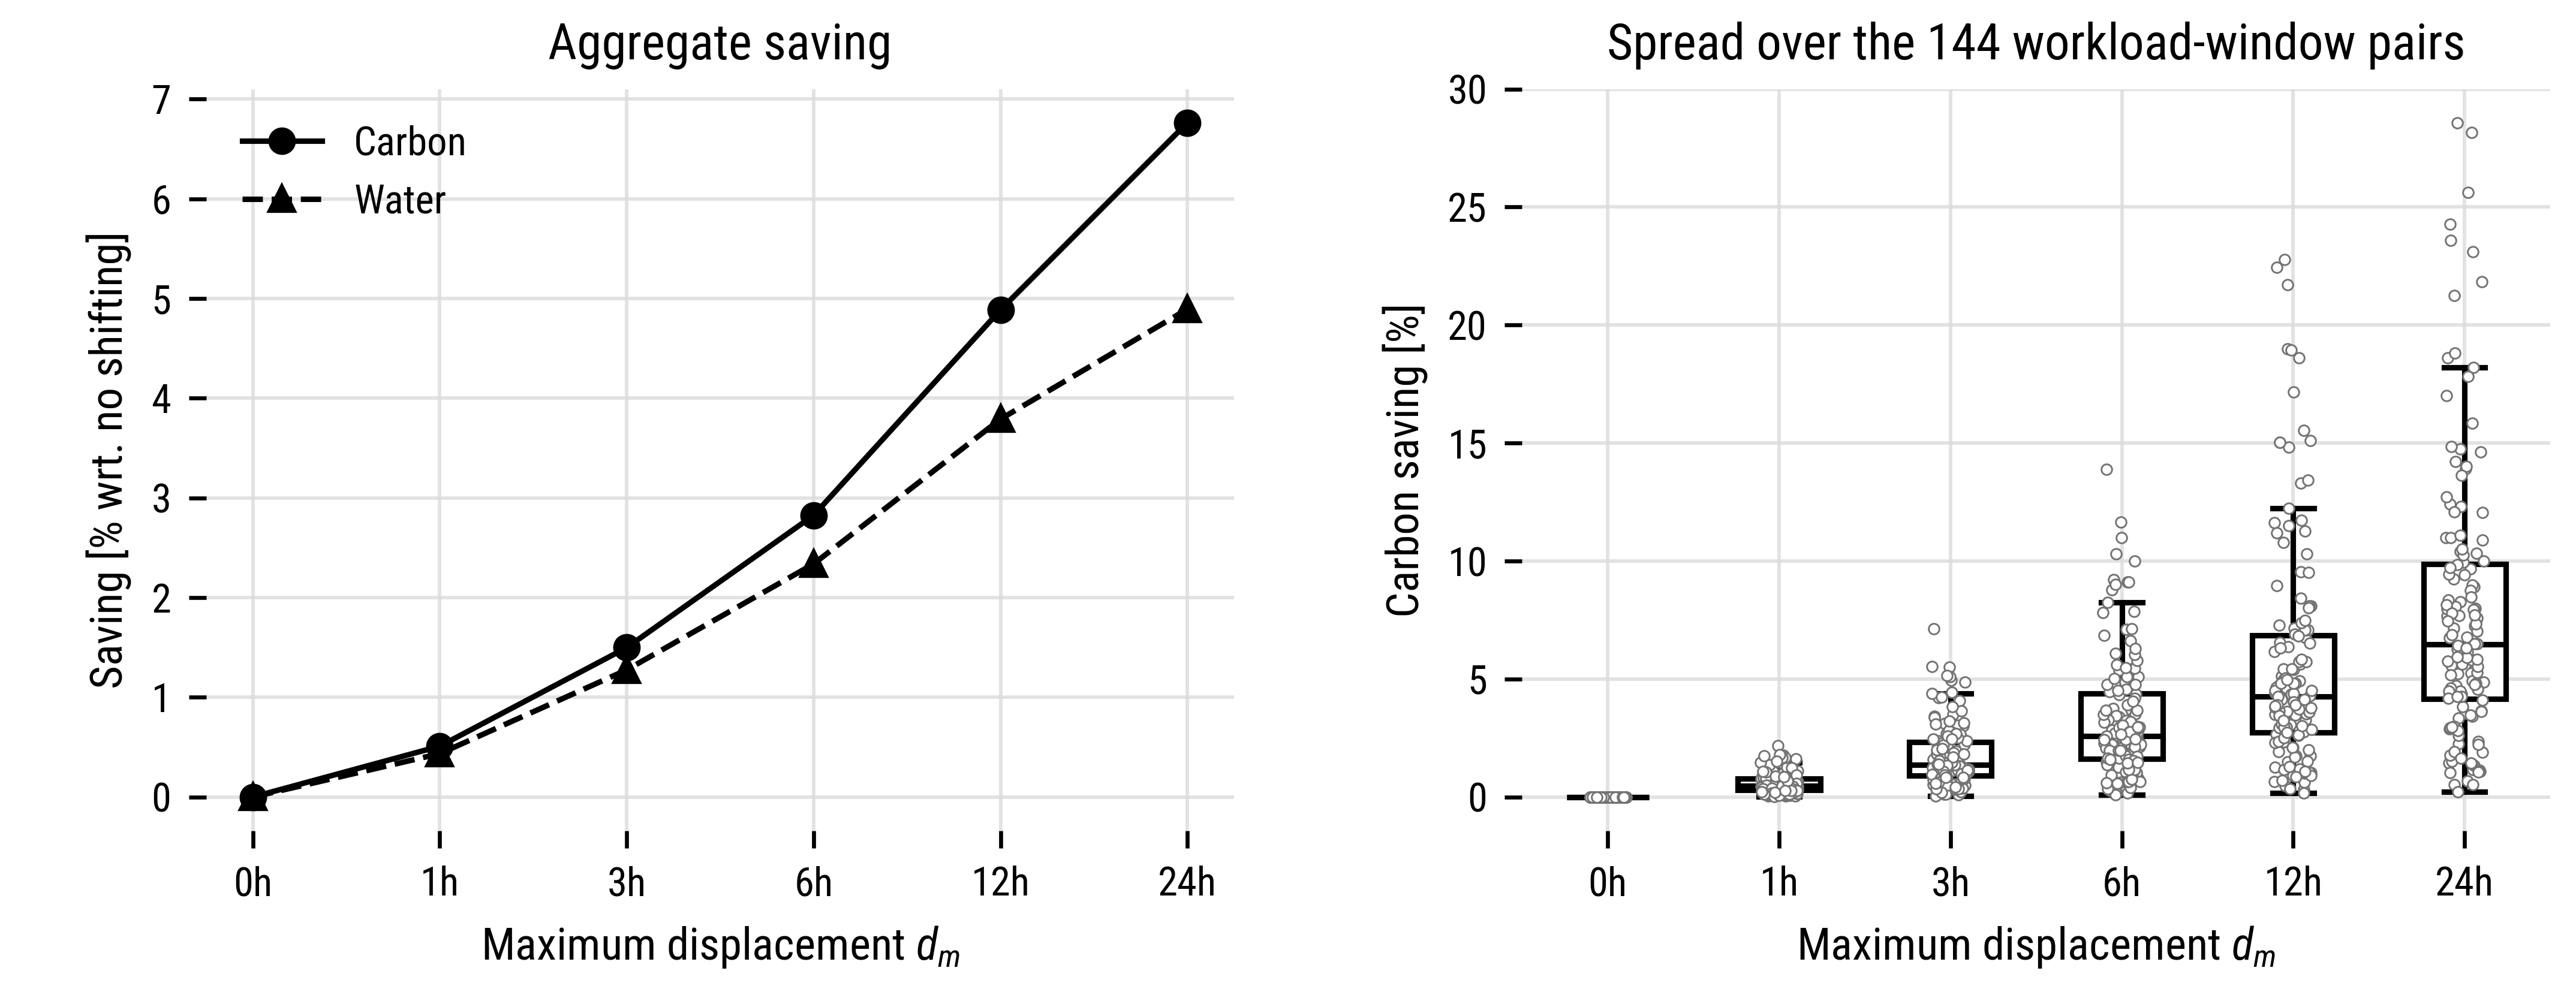

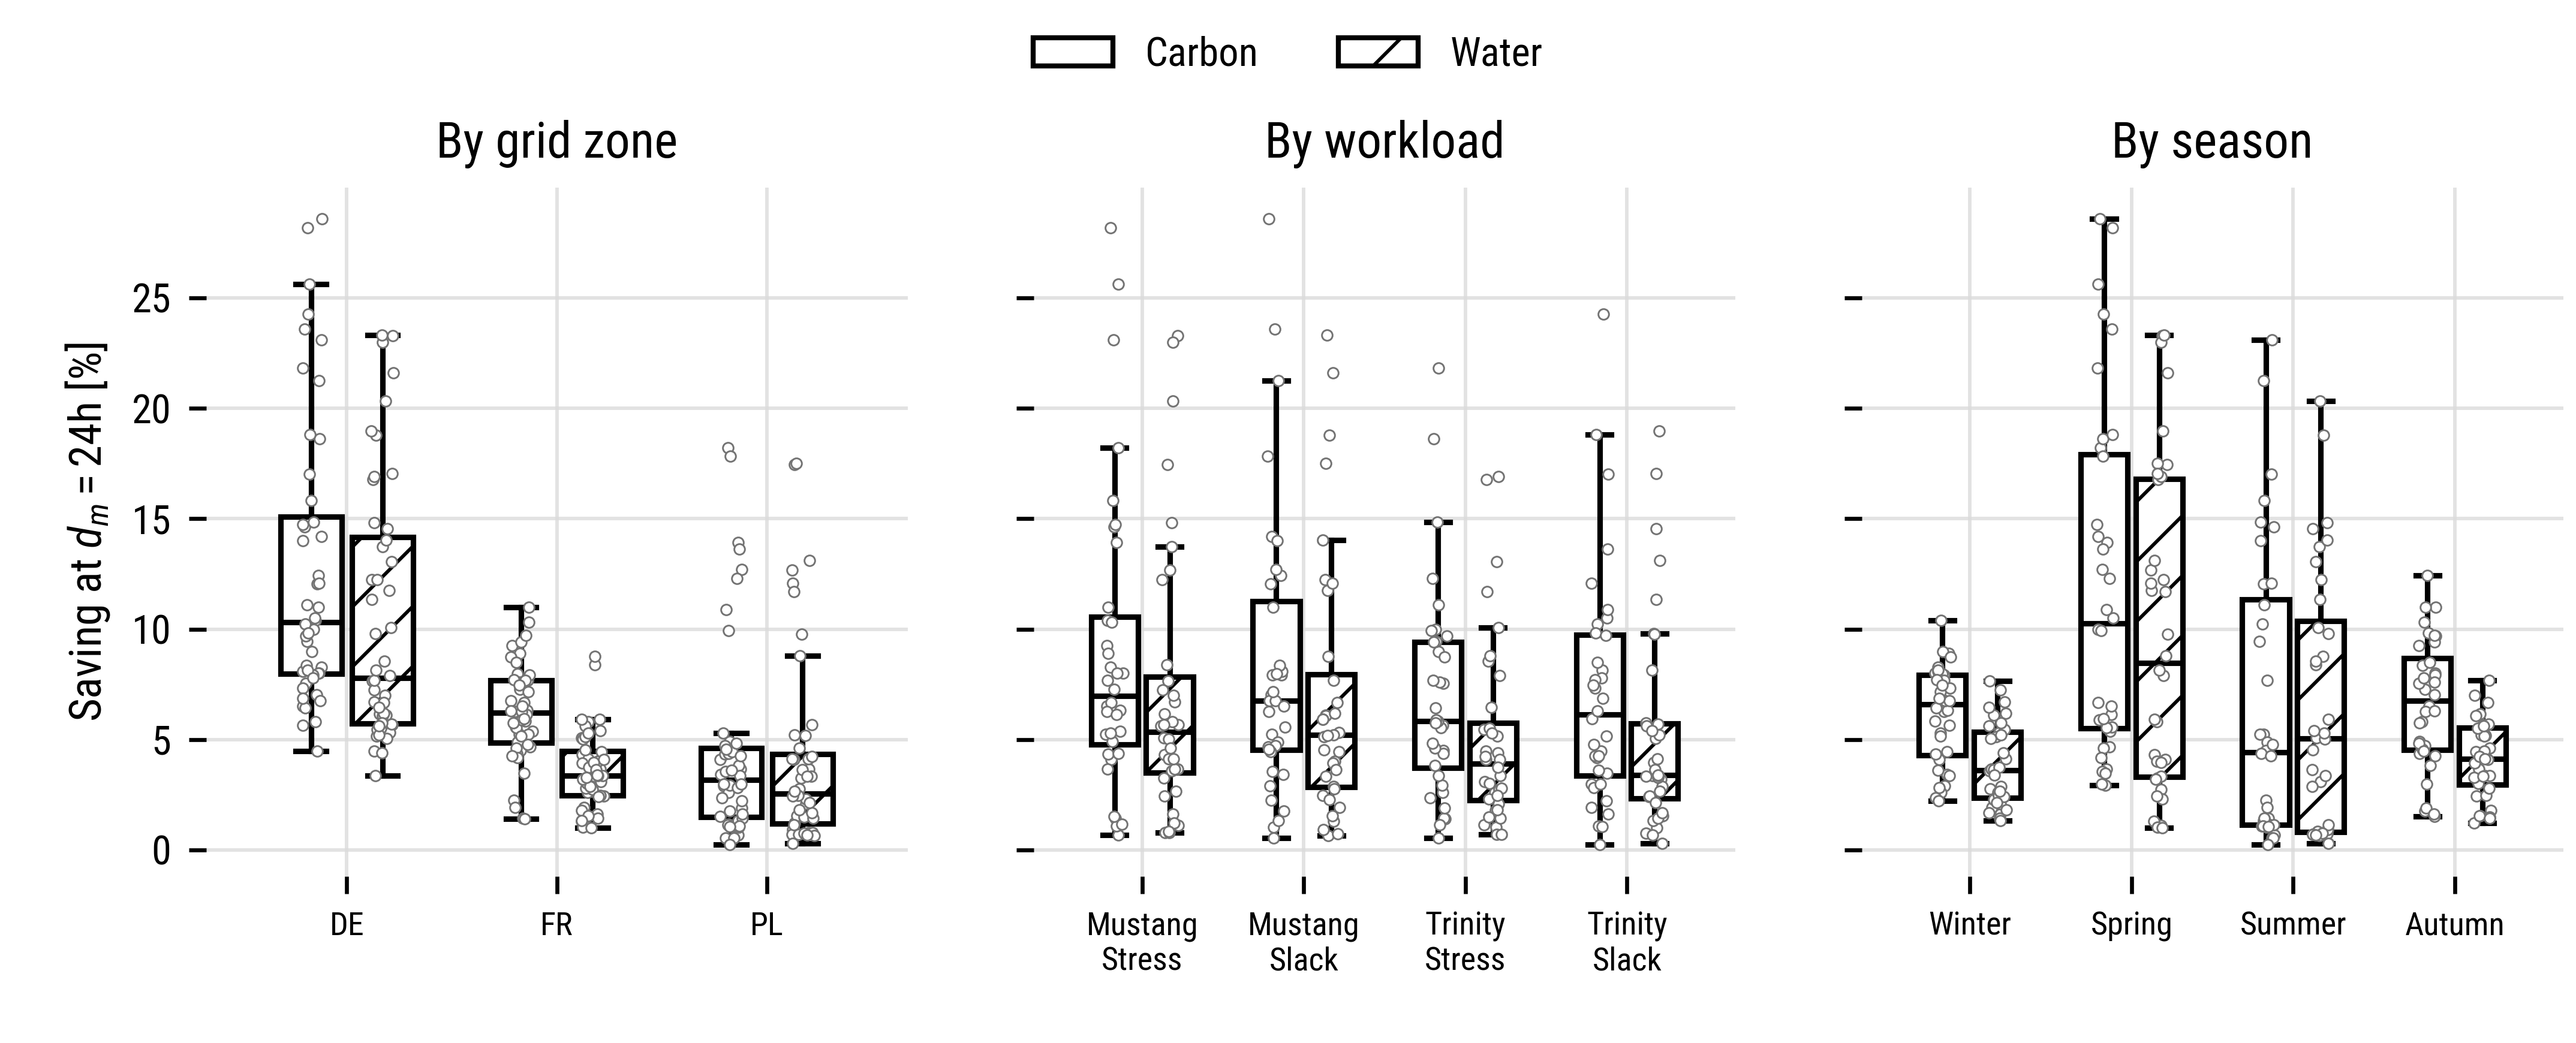

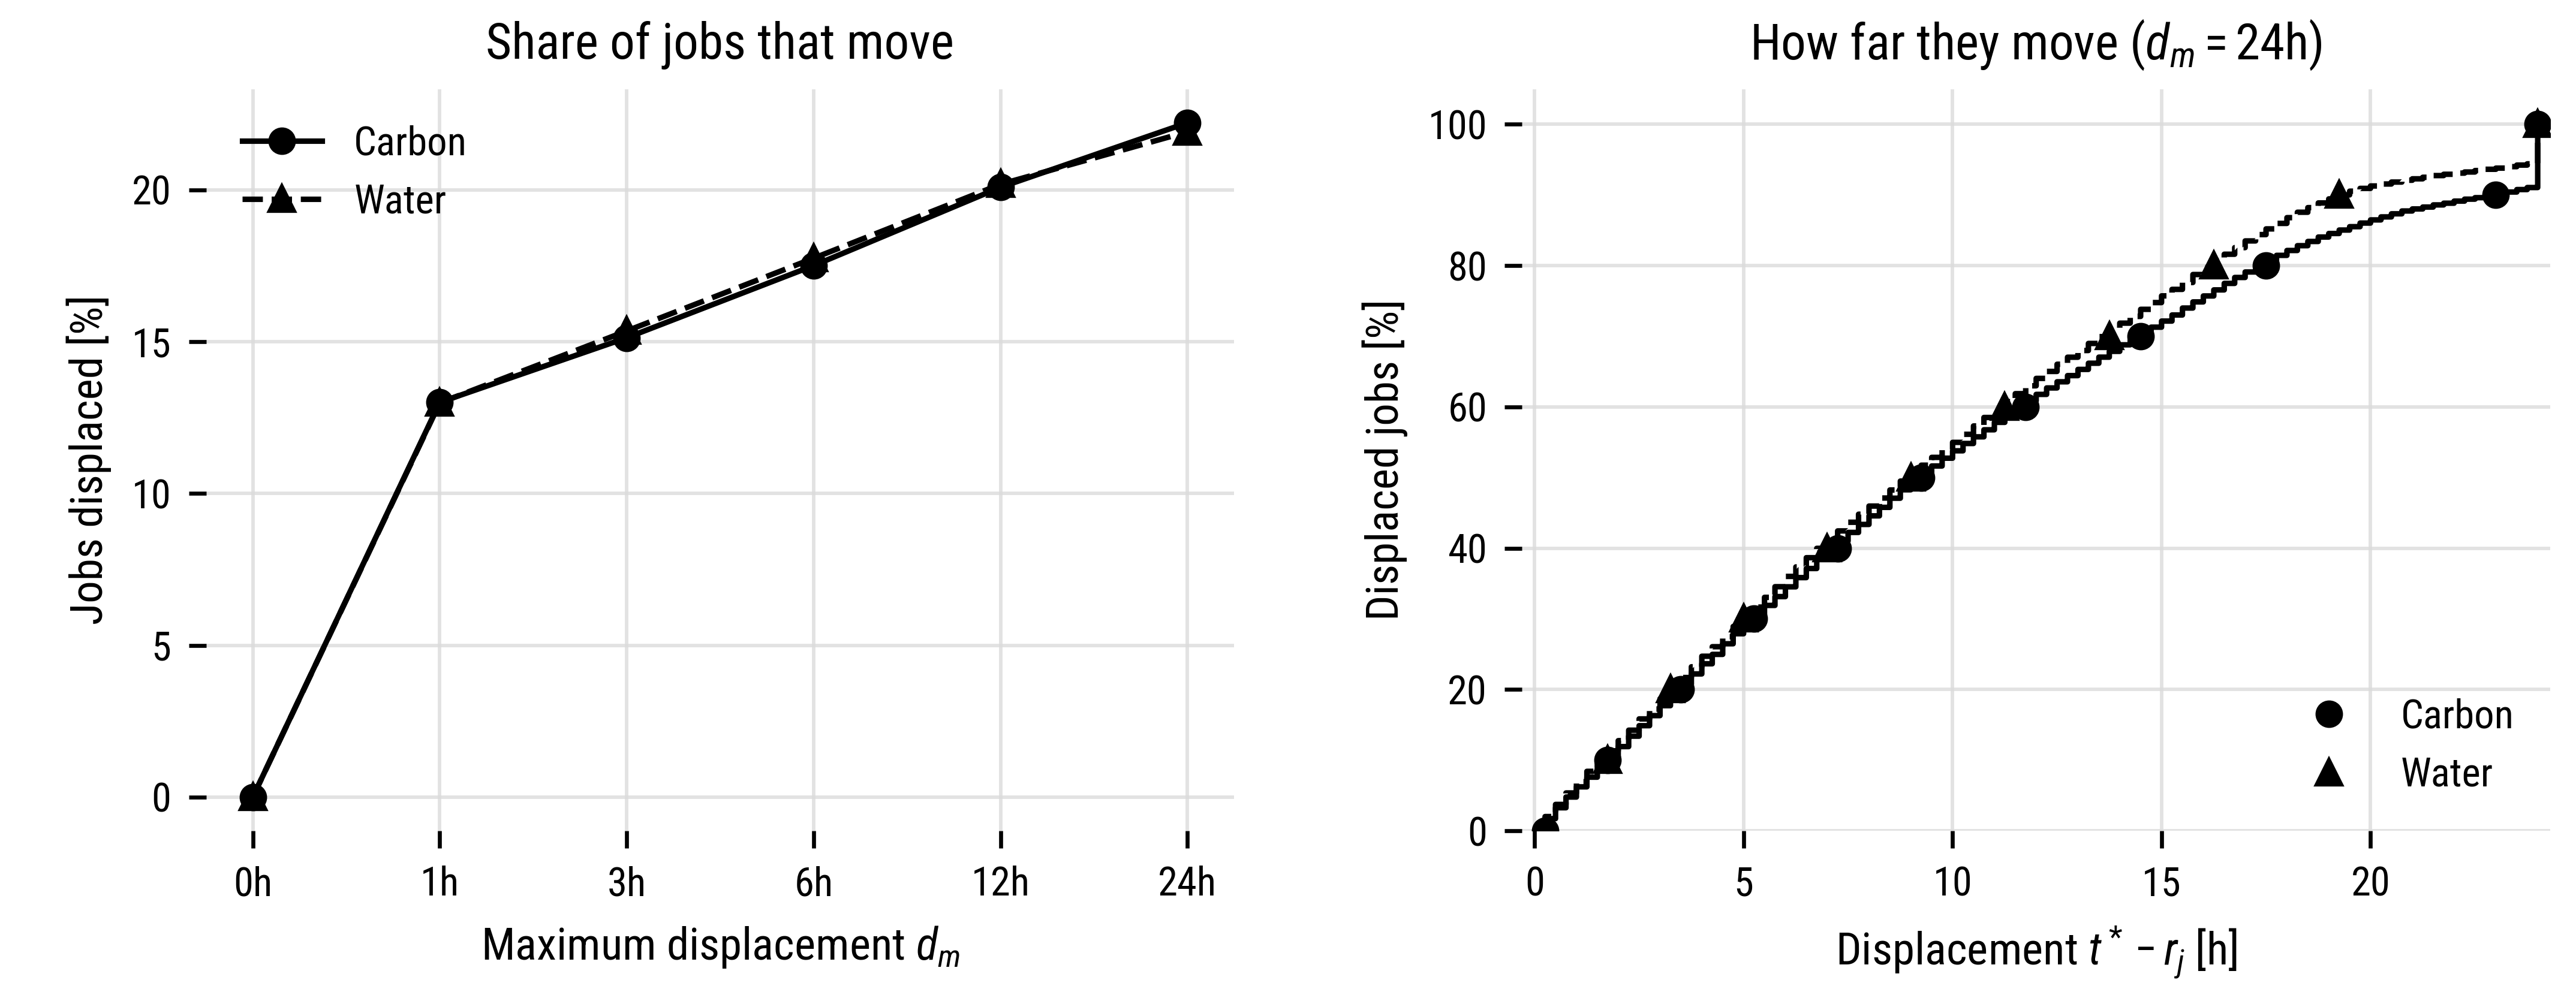

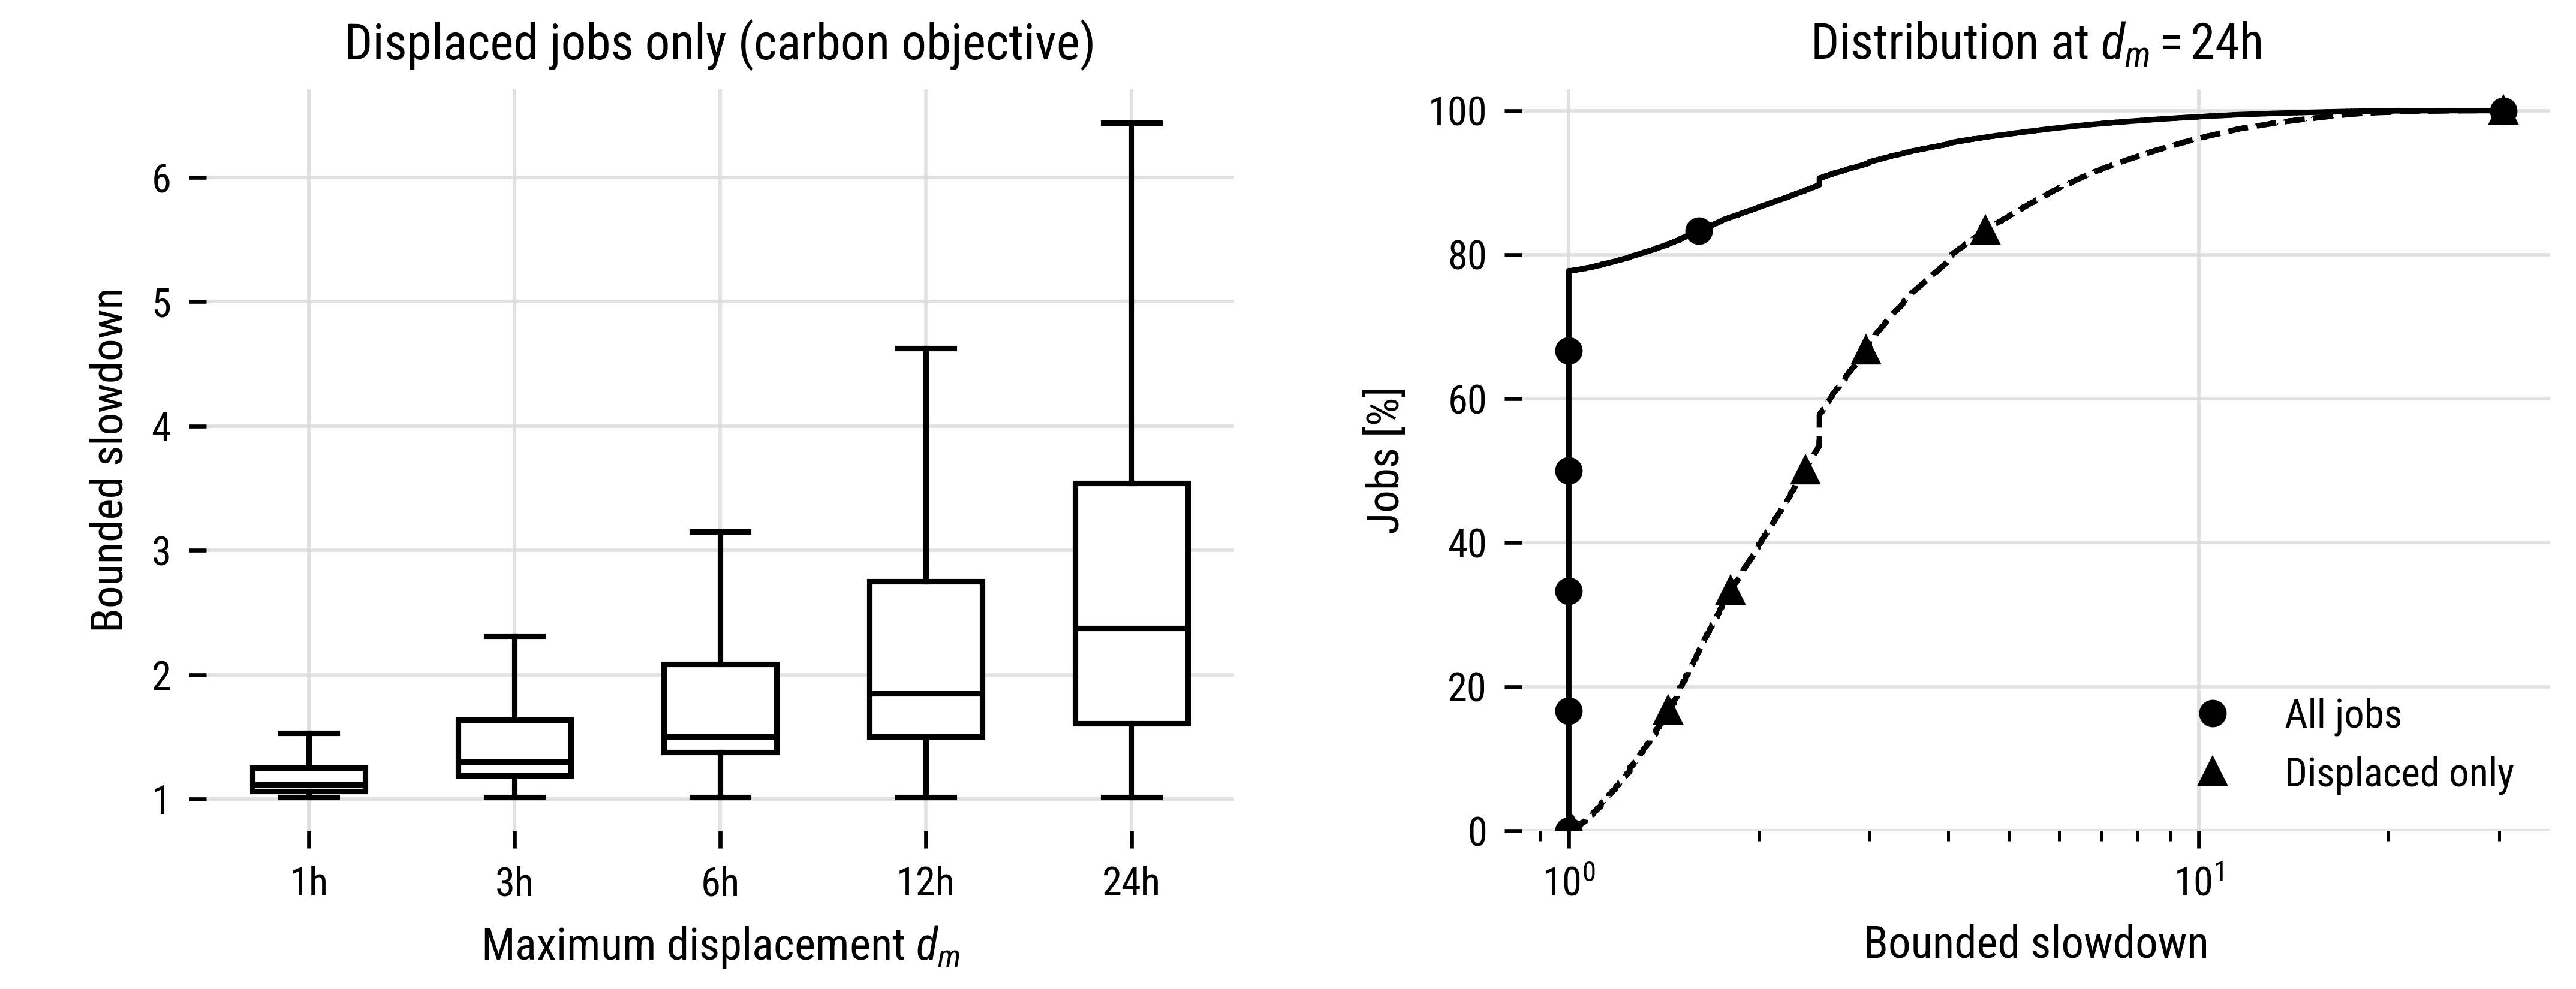

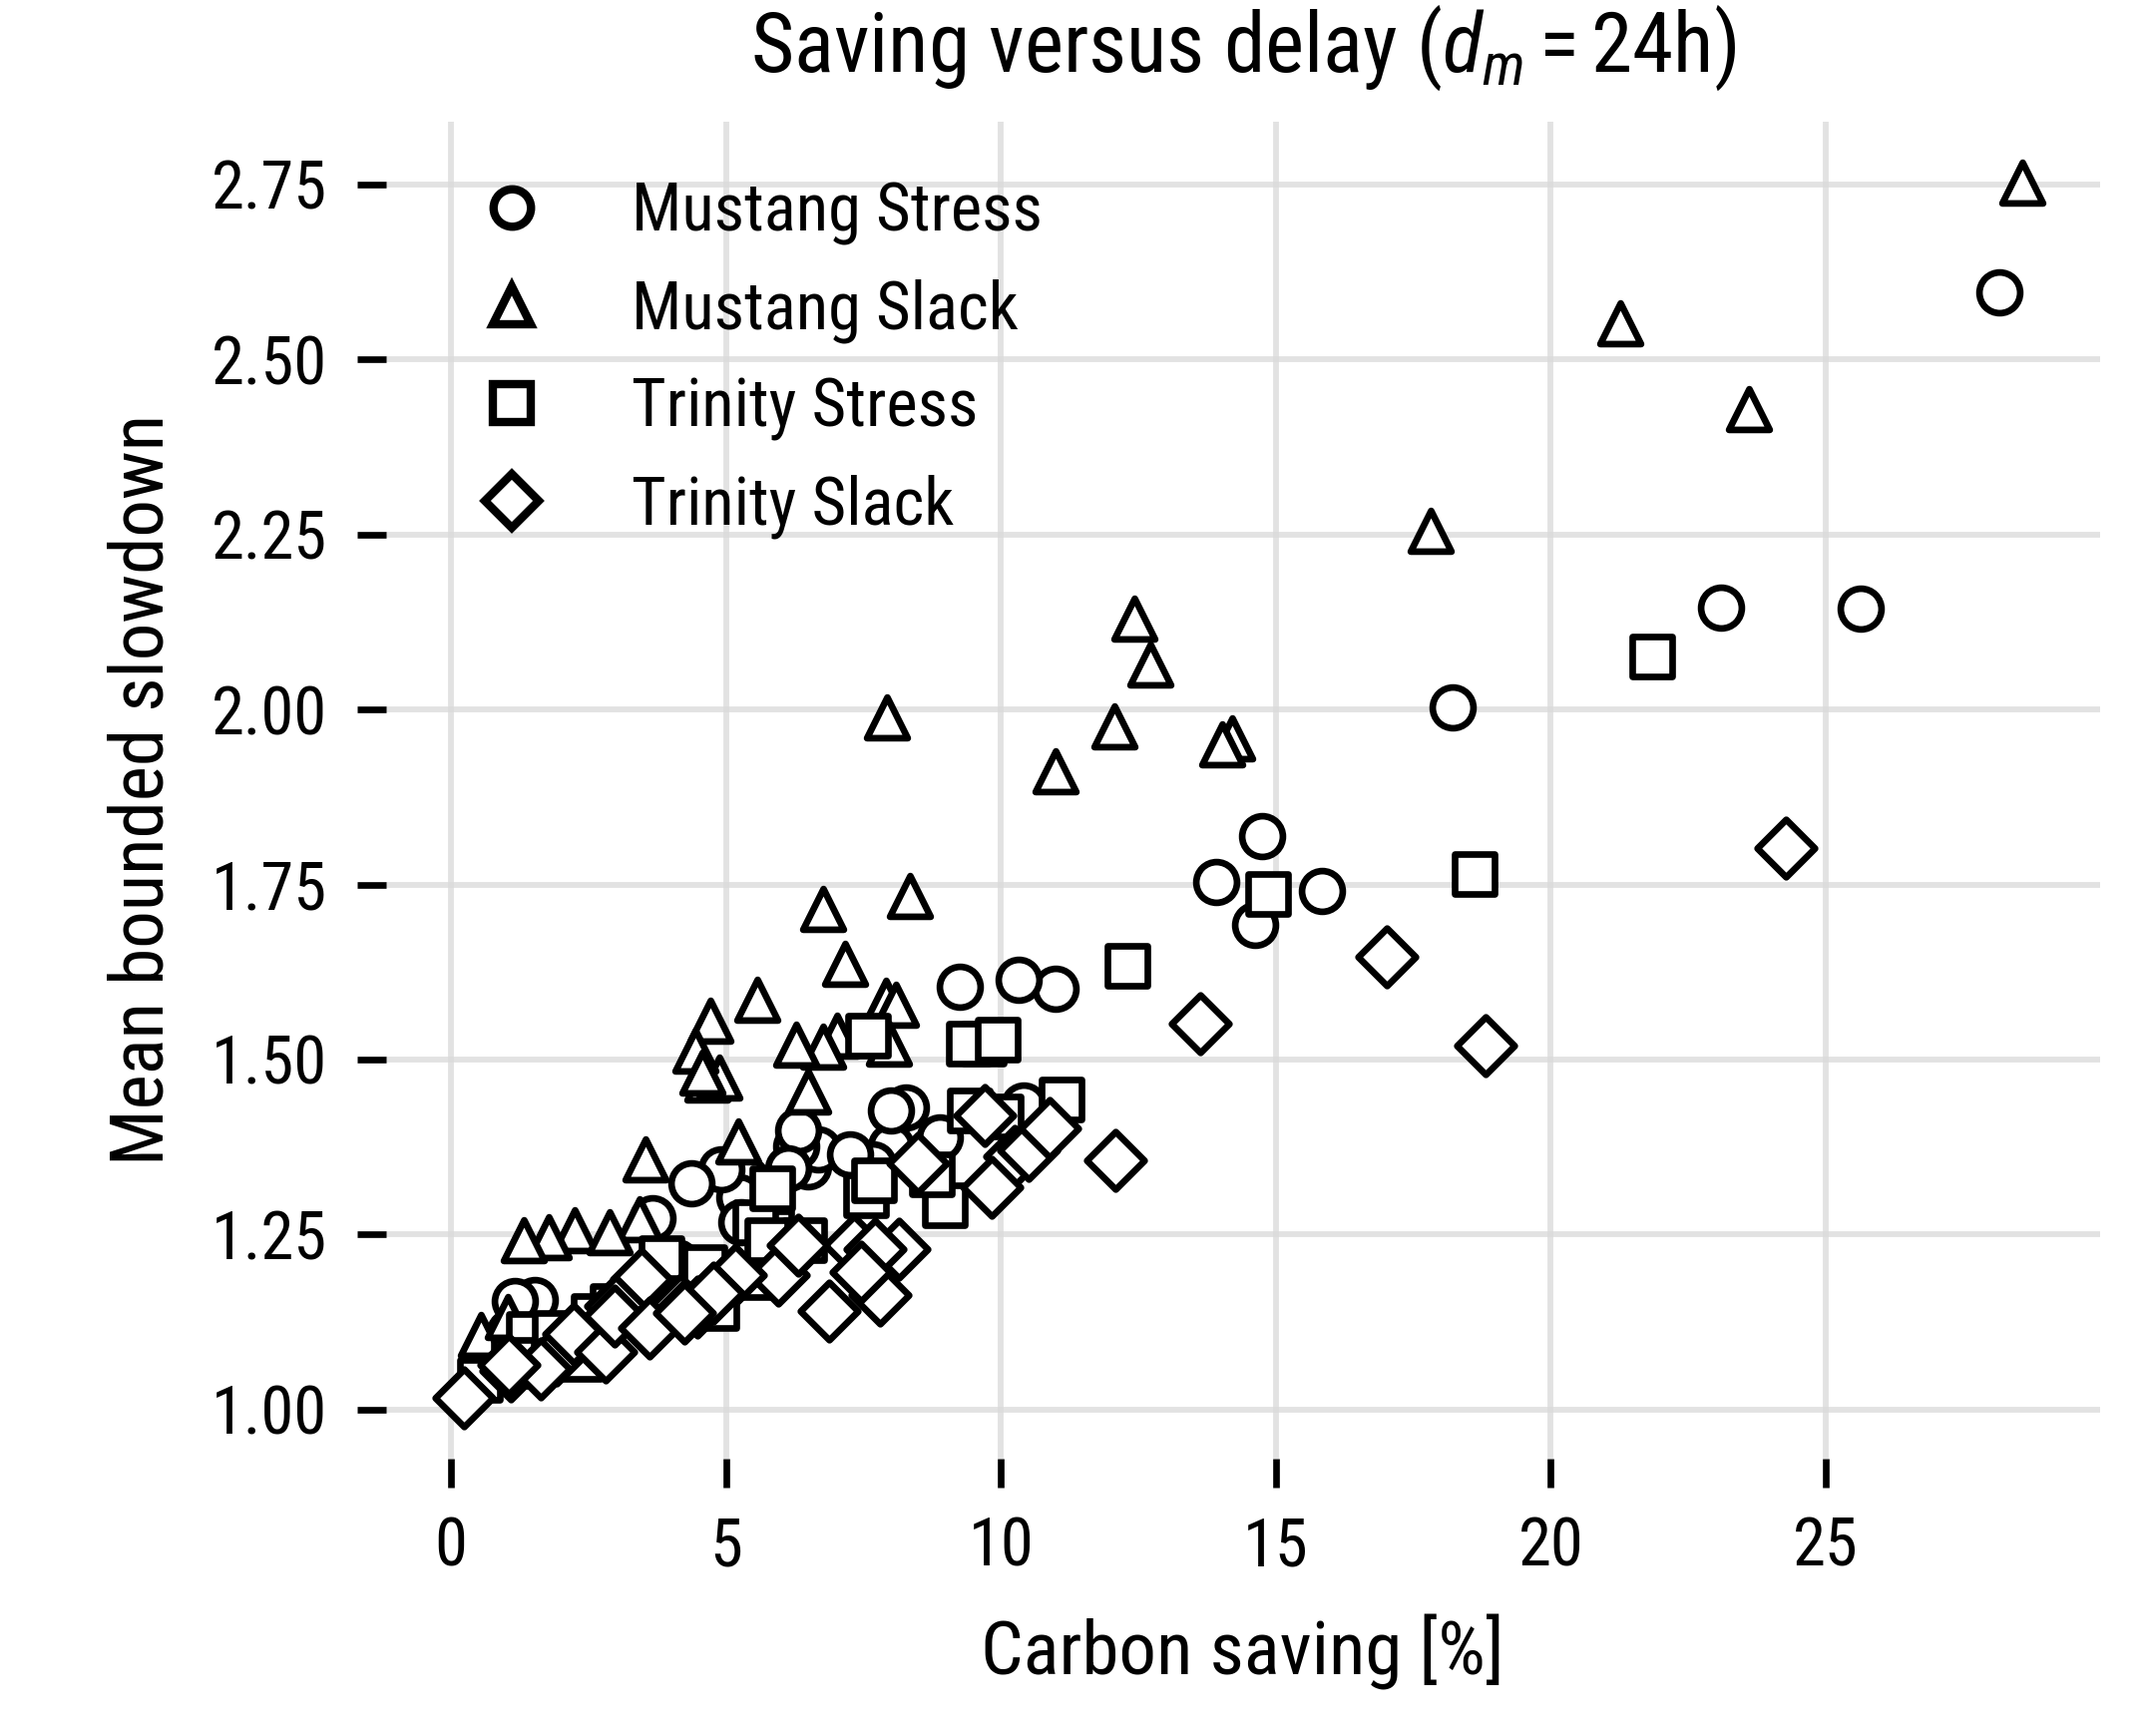

In [7]:
from IPython.display import Image, display

for path in figure_paths:
    if path.suffix == '.png':
        display(Image(filename=path))